# COMP-341L — Lab 12 (GANs): Synthetic Handwritten Digits

**Instructor:** Ms. Shakeela Shaheen  
**Student:** Zarmeena Jawad  
**Roll No:** B23F0115AI125  
**Section:** B.S AI - Red  
**Platform:** Google Colab

## Quick Idea
A **GAN** trains two networks together:
- **Generator (G):** creates fake digits from random noise
- **Discriminator (D):** judges if a digit is real or fake

They learn by competing (minimax game). The goal is to make the generated digits look realistic.

## What you will produce
- A trained GAN on MNIST digits (CSV or torchvision fallback)
- Loss plots (G loss vs D loss)
- Real vs Fake visual comparison
- Exported report: `Lab_Report_12.md` and `Lab_Report_12.html`


In [1]:
import os
from datetime import datetime

try:
    from google.colab import drive  # type: ignore
    IN_COLAB = True
except Exception:
    IN_COLAB = False

STUDENT_NAME = "Zarmeena Jawad"
STUDENT_ROLL = "B23F0115AI125"
STUDENT_SECTION = "B.S AI - Red"
STUDENT_FOLDER_NAME = "Zarmeena's Lab"
USE_GOOGLE_DRIVE = True

if IN_COLAB:
    if not USE_GOOGLE_DRIVE:
        raise RuntimeError("Set USE_GOOGLE_DRIVE=True to save outputs on Google Drive.")

    drive.mount("/content/drive", force_remount=True)
    BASE_DIR = f"/content/drive/MyDrive/COMP-341L/Lab 12/{STUDENT_FOLDER_NAME}"
    print("Drive mounted.")
else:
    BASE_DIR = os.environ.get("LAB12_BASE_DIR", ".")

DATA_DIR = os.path.join(BASE_DIR, "data")
OUT_DIR = os.path.join(BASE_DIR, "outputs")
PLOTS_DIR = os.path.join(OUT_DIR, "plots")
SAMPLES_DIR = os.path.join(OUT_DIR, "samples")

os.makedirs(DATA_DIR, exist_ok=True)
os.makedirs(PLOTS_DIR, exist_ok=True)
os.makedirs(SAMPLES_DIR, exist_ok=True)

print("IN_COLAB :", IN_COLAB)
print("BASE_DIR :", os.path.abspath(BASE_DIR))
print("DATA_DIR :", os.path.abspath(DATA_DIR))
print("OUT_DIR  :", os.path.abspath(OUT_DIR))
print("PLOTS_DIR:", os.path.abspath(PLOTS_DIR))
print("SAMPLES_DIR:", os.path.abspath(SAMPLES_DIR))


Mounted at /content/drive
Drive mounted.
IN_COLAB : True
BASE_DIR : /content/drive/MyDrive/COMP-341L/Lab 12/Zarmeena's Lab
DATA_DIR : /content/drive/MyDrive/COMP-341L/Lab 12/Zarmeena's Lab/data
OUT_DIR  : /content/drive/MyDrive/COMP-341L/Lab 12/Zarmeena's Lab/outputs
PLOTS_DIR: /content/drive/MyDrive/COMP-341L/Lab 12/Zarmeena's Lab/outputs/plots
SAMPLES_DIR: /content/drive/MyDrive/COMP-341L/Lab 12/Zarmeena's Lab/outputs/samples


## Task 1 — Data Preparation (MNIST from CSV)

Target dataset (Kaggle): **MNIST in CSV** (`oddrationale/mnist-in-csv`)

**Colab note:** If you upload `kaggle.json`, the notebook downloads the Kaggle CSV.
If not, it automatically falls back to `torchvision.datasets.MNIST` so you can still finish the lab.


DEVICE: cuda
{'latent_dim': 100, 'batch_size': 128, 'lr': 0.0002, 'betas': (0.5, 0.999), 'num_epochs': 15}
Kaggle: False kaggle.json not found.
Fallback: torchvision MNIST


100%|██████████| 9.91M/9.91M [00:00<00:00, 11.9MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 367kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 3.32MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 16.6MB/s]


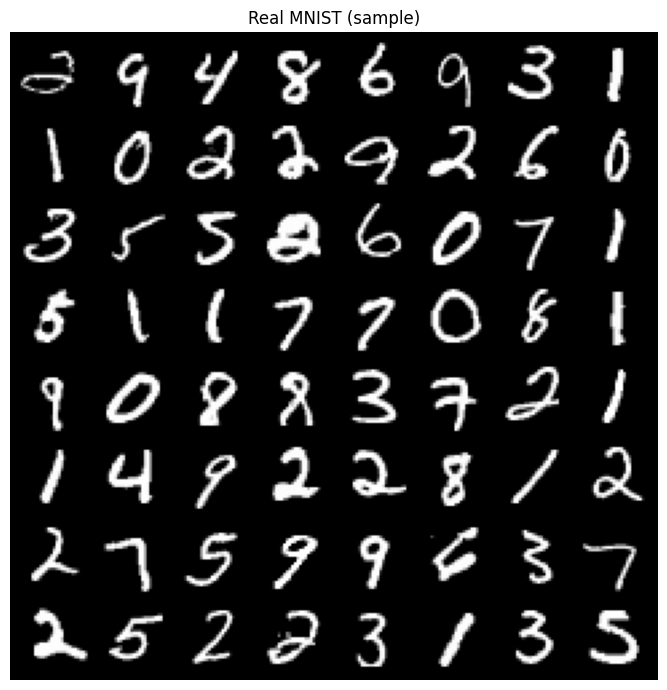

Saved: /content/drive/MyDrive/COMP-341L/Lab 12/Zarmeena's Lab/outputs/plots/task1_real_grid.png


In [2]:
import random
import shutil
import subprocess
import sys
import zipfile
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as T
from IPython.display import display
from torch.utils.data import DataLoader, Dataset
from tqdm.auto import tqdm

SEED = 7
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("DEVICE:", DEVICE)

# --- Hyperparameters (Task 3 / Task 5) ---
latent_dim = 100
batch_size = 128
lr = 2e-4
beta1, beta2 = 0.5, 0.999
num_epochs = 15  # 10–20 recommended

print(
    {
        "latent_dim": latent_dim,
        "batch_size": batch_size,
        "lr": lr,
        "betas": (beta1, beta2),
        "num_epochs": num_epochs,
    }
)


def _pip_install(pkg: str):
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", pkg], check=True)


def _try_kaggle_download(dataset: str, out_dir: str):
    kaggle_json_candidates = [
        "/content/kaggle.json",
        os.path.expanduser("~/.kaggle/kaggle.json"),
    ]
    kaggle_json_path = next(
        (p for p in kaggle_json_candidates if os.path.exists(p)), None
    )
    if kaggle_json_path is None:
        return False, "kaggle.json not found."

    _pip_install("kaggle")

    kaggle_dir = os.path.expanduser("~/.kaggle")
    os.makedirs(kaggle_dir, exist_ok=True)
    dst = os.path.join(kaggle_dir, "kaggle.json")
    if os.path.abspath(kaggle_json_path) != os.path.abspath(dst):
        shutil.copyfile(kaggle_json_path, dst)
    os.chmod(dst, 0o600)

    subprocess.run(
        ["kaggle", "datasets", "download", "-d", dataset, "-p", out_dir, "--unzip"],
        check=True,
    )

    for zp in Path(out_dir).glob("*.zip"):
        try:
            with zipfile.ZipFile(str(zp), "r") as zf:
                zf.extractall(out_dir)
        except zipfile.BadZipFile:
            pass

    return True, f"Downloaded: {dataset}"


def _find_csv(search_dir: str):
    candidates = list(Path(search_dir).rglob("*.csv"))
    if not candidates:
        return None
    # prefer train-like files
    candidates.sort(key=lambda p: (("train" not in p.name.lower()), p.name.lower()))
    return str(candidates[0])


def load_mnist_csv(csv_path: str):
    df = pd.read_csv(csv_path)
    if "label" in df.columns:
        labels = df["label"].to_numpy().astype("int64")
        pixels = df.drop(columns=["label"]).to_numpy().astype("float32")
    else:
        labels = df.iloc[:, 0].to_numpy().astype("int64")
        pixels = df.iloc[:, 1:].to_numpy().astype("float32")

    if pixels.shape[1] != 784:
        raise ValueError(f"Expected 784 pixels, got {pixels.shape[1]} from {csv_path}")
    images = pixels.reshape(-1, 28, 28)
    return images, labels


class MNISTFlatDataset(Dataset):
    def __init__(self, images_01: np.ndarray):
        self.images_01 = images_01

    def __len__(self):
        return int(self.images_01.shape[0])

    def __getitem__(self, idx):
        x = self.images_01[idx]  # [0,1], (28,28)
        x = (x - 0.5) / 0.5  # -> [-1,1]
        x = torch.from_numpy(x).float().view(-1)  # 784
        return x


DATA_SOURCE = "kaggle"
ok, msg = _try_kaggle_download("oddrationale/mnist-in-csv", DATA_DIR)
print("Kaggle:", ok, msg)
if not ok:
    DATA_SOURCE = "torchvision"

if DATA_SOURCE == "kaggle":
    csv_path = _find_csv(DATA_DIR)
    if csv_path is None:
        raise FileNotFoundError(f"No CSV found in {DATA_DIR}")
    images, labels = load_mnist_csv(csv_path)
    images_01 = (images / 255.0).astype("float32")
    dataset = MNISTFlatDataset(images_01)
    print("Using CSV:", csv_path, "images:", images_01.shape)
else:
    print("Fallback: torchvision MNIST")
    tfm = T.Compose([T.ToTensor(), T.Normalize((0.5,), (0.5,))])  # -> [-1,1]
    tv = torchvision.datasets.MNIST(root=DATA_DIR, train=True, download=True, transform=tfm)

    class _TorchvisionFlat(Dataset):
        def __init__(self, ds):
            self.ds = ds

        def __len__(self):
            return len(self.ds)

        def __getitem__(self, idx):
            x, _y = self.ds[idx]
            return x.view(-1)

    dataset = _TorchvisionFlat(tv)

dataloader = DataLoader(
    dataset,
    batch_size=batch_size,
    shuffle=True,
    drop_last=True,
    num_workers=2,
    pin_memory=torch.cuda.is_available(),
)

# Visual check: show a few real digits
real_flat = next(iter(dataloader))[:64]
real_imgs = real_flat.view(-1, 1, 28, 28)
grid = torchvision.utils.make_grid(real_imgs, nrow=8, normalize=True, value_range=(-1, 1))

plt.figure(figsize=(7, 7))
plt.imshow(grid.permute(1, 2, 0).cpu().numpy())
plt.title("Real MNIST (sample)")
plt.axis("off")
plt.tight_layout()
path = os.path.join(PLOTS_DIR, "task1_real_grid.png")
plt.savefig(path, dpi=170, bbox_inches="tight")
plt.show()
print("Saved:", path)


## Task 2 — GAN Implementation (Vanilla GAN / MLP)

To keep things clear, we implement a **Vanilla GAN** using fully-connected layers:
- Generator: `z (latent_dim)` → `784` pixels (28×28)
- Discriminator: `784` pixels → real/fake score

Notes:
- Generator uses `tanh` so outputs are in `[-1, 1]`
- Discriminator returns **logits** (no sigmoid). We use `BCEWithLogitsLoss`.


In [3]:
image_dim = 28 * 28


class Generator(nn.Module):
    def __init__(self, z_dim: int, out_dim: int):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(z_dim, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(True),
            nn.Linear(256, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(True),
            nn.Linear(512, 1024),
            nn.BatchNorm1d(1024),
            nn.ReLU(True),
            nn.Linear(1024, out_dim),
            nn.Tanh(),
        )

    def forward(self, z):
        return self.net(z)


class Discriminator(nn.Module):
    def __init__(self, in_dim: int):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, 512),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Dropout(0.2),
            nn.Linear(512, 256),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Dropout(0.2),
            nn.Linear(256, 1),  # logits
        )

    def forward(self, x):
        return self.net(x).view(-1, 1)


G = Generator(latent_dim, image_dim).to(DEVICE)
D = Discriminator(image_dim).to(DEVICE)

def count_params(m):
    return sum(p.numel() for p in m.parameters() if p.requires_grad)

print("G params:", count_params(G))
print("D params:", count_params(D))


G params: 1489936
D params: 533505


## Task 3 — Training (10–20 epochs)

Training steps:
1) Update **D** using real=1 and fake=0  
2) Update **G** to make fake look real (target=1)


Epoch 1/15:   0%|          | 0/468 [00:00<?, ?it/s]

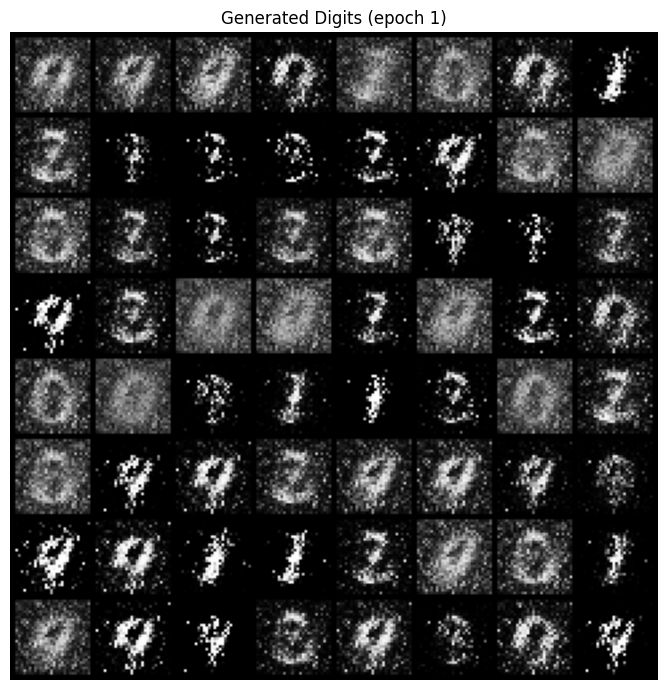

Saved: /content/drive/MyDrive/COMP-341L/Lab 12/Zarmeena's Lab/outputs/samples/epoch_001.png


Epoch 2/15:   0%|          | 0/468 [00:00<?, ?it/s]

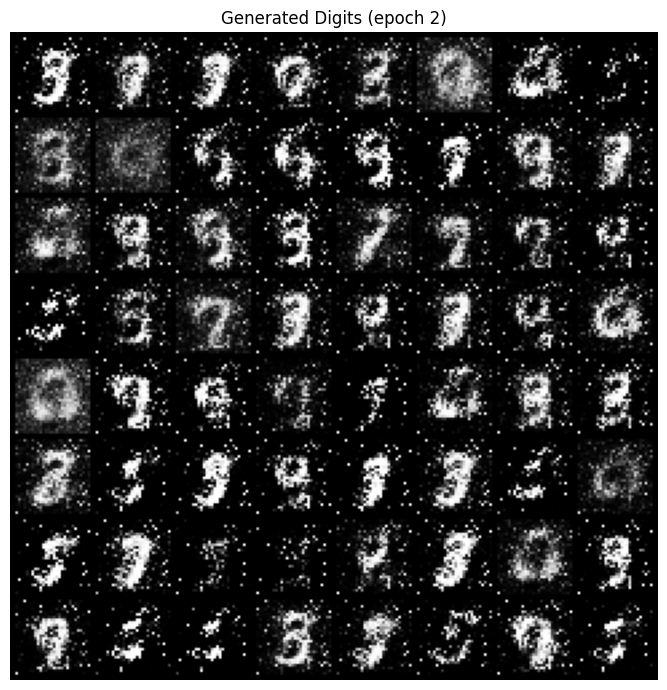

Saved: /content/drive/MyDrive/COMP-341L/Lab 12/Zarmeena's Lab/outputs/samples/epoch_002.png


Epoch 3/15:   0%|          | 0/468 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7c1266d6f920>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    if w.is_alive():
       ^^^Exception ignored in: ^<function _MultiProcessingDataLoaderIter.__del__ at 0x7c1266d6f920>^^
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
^    self._shutdown_workers()^
^^  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
^    ^if w.is_alive():

   File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
      assert self._parent_pid == os.getpid(), 'can only test a child process' 
       ^ ^ ^ ^^  ^^  ^^^^^^^^^
^  File 

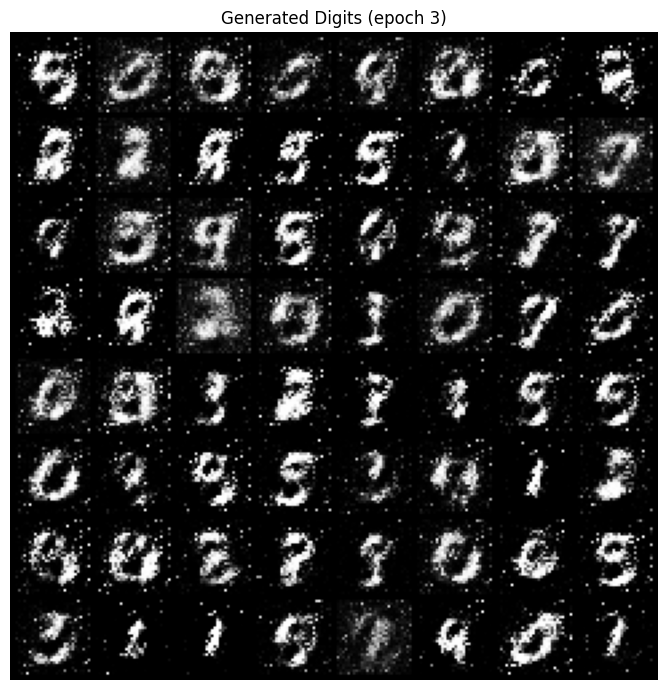

Saved: /content/drive/MyDrive/COMP-341L/Lab 12/Zarmeena's Lab/outputs/samples/epoch_003.png


Epoch 4/15:   0%|          | 0/468 [00:00<?, ?it/s]

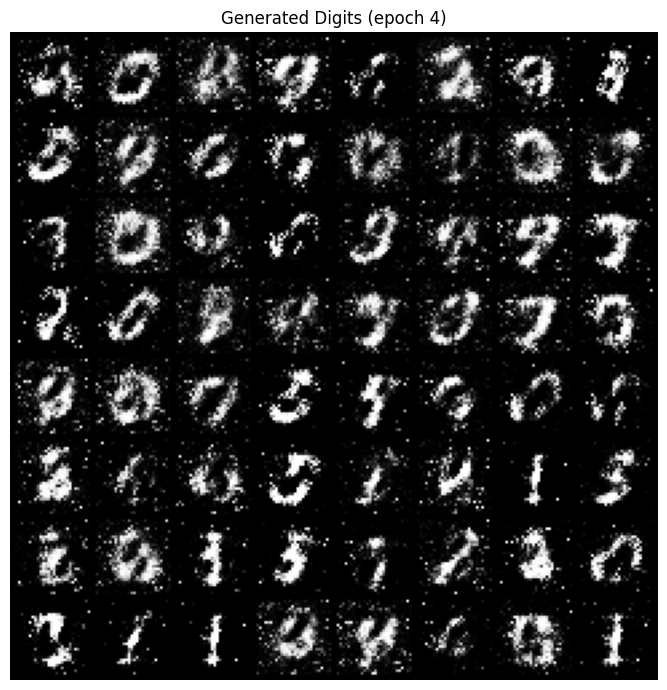

Saved: /content/drive/MyDrive/COMP-341L/Lab 12/Zarmeena's Lab/outputs/samples/epoch_004.png


Epoch 5/15:   0%|          | 0/468 [00:00<?, ?it/s]

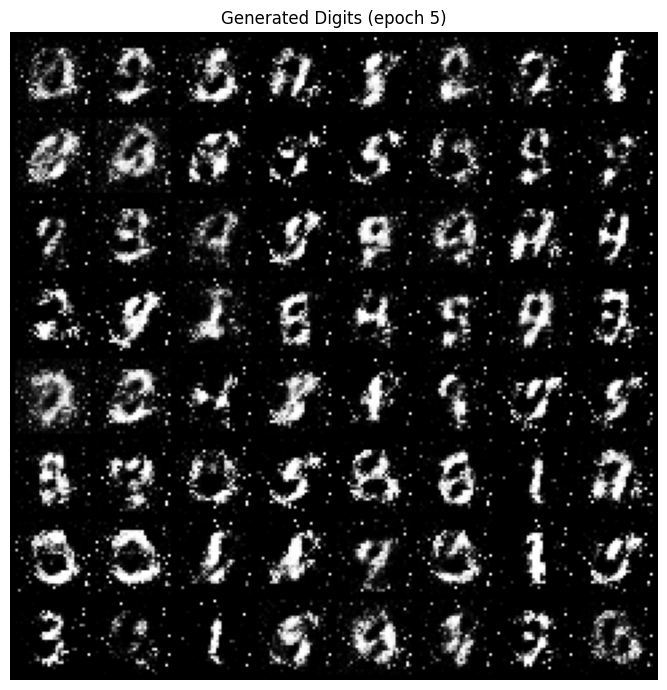

Saved: /content/drive/MyDrive/COMP-341L/Lab 12/Zarmeena's Lab/outputs/samples/epoch_005.png


Epoch 6/15:   0%|          | 0/468 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7c1266d6f920>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7c1266d6f920>
Exception ignored in: 
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
Traceback (most recent call last):
<function _MultiProcessingDataLoaderIter.__del__ at 0x7c1266d6f920>  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    
if w.is_alive():Traceback (most recent call last):
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
 
   File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
         

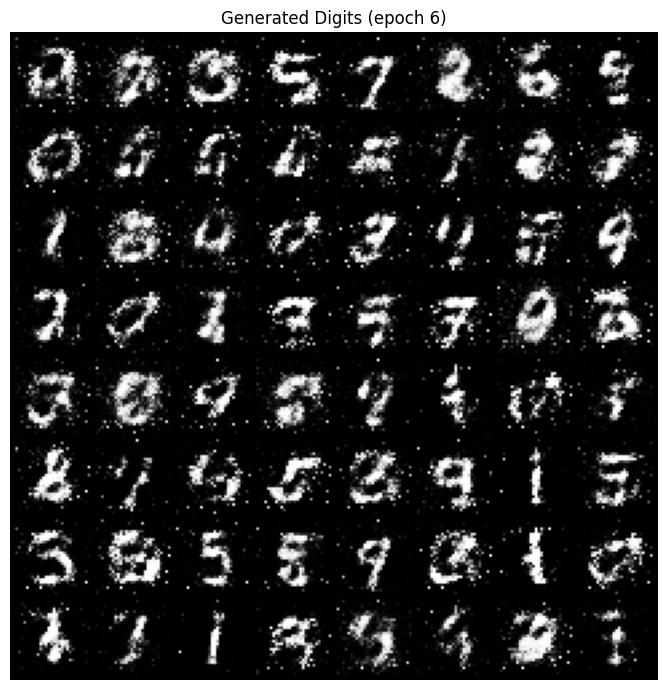

Saved: /content/drive/MyDrive/COMP-341L/Lab 12/Zarmeena's Lab/outputs/samples/epoch_006.png


Epoch 7/15:   0%|          | 0/468 [00:00<?, ?it/s]

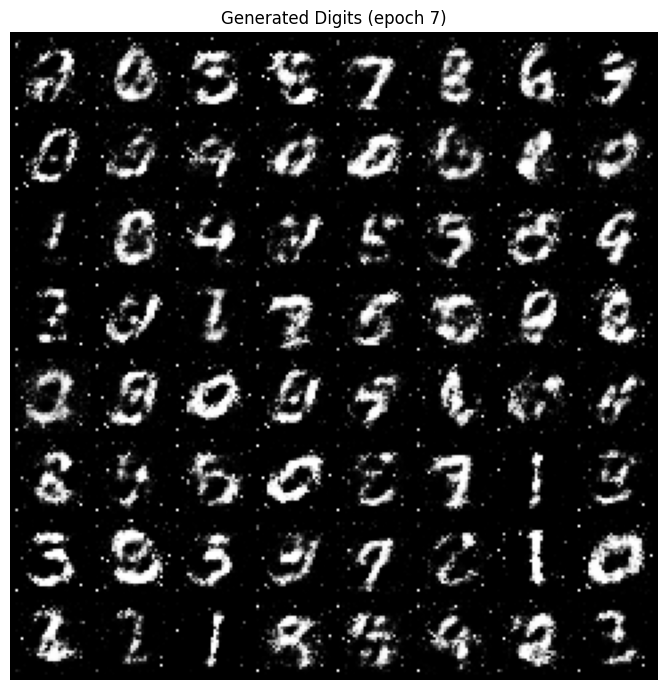

Saved: /content/drive/MyDrive/COMP-341L/Lab 12/Zarmeena's Lab/outputs/samples/epoch_007.png


Epoch 8/15:   0%|          | 0/468 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7c1266d6f920>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    Exception ignored in: if w.is_alive():<function _MultiProcessingDataLoaderIter.__del__ at 0x7c1266d6f920>
 
Traceback (most recent call last):
    File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
        self._shutdown_workers()
^  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
^    ^^if w.is_alive():
^ ^ ^ ^ ^ ^^ ^
   File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
^    assert self._parent_pid == os.getpid(), 'can only test a child process'^
^ ^ ^ ^^ ^ ^^ ^^ 
   File "/usr/li

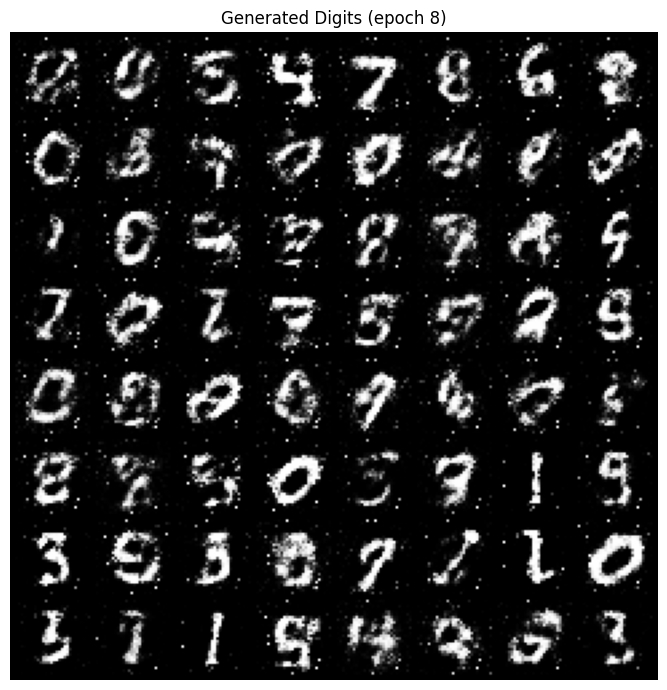

Saved: /content/drive/MyDrive/COMP-341L/Lab 12/Zarmeena's Lab/outputs/samples/epoch_008.png


Epoch 9/15:   0%|          | 0/468 [00:00<?, ?it/s]

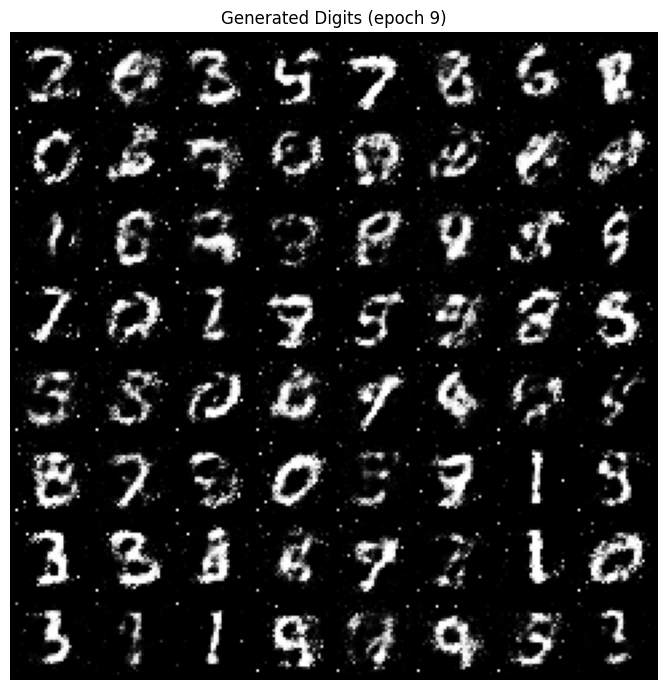

Saved: /content/drive/MyDrive/COMP-341L/Lab 12/Zarmeena's Lab/outputs/samples/epoch_009.png


Epoch 10/15:   0%|          | 0/468 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7c1266d6f920>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
Exception ignored in:     self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    if w.is_alive():
    <function _MultiProcessingDataLoaderIter.__del__ at 0x7c1266d6f920> 
 Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
 ^^    ^self._shutdown_workers()^
^  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
^    ^if w.is_alive():^
^ ^ ^ ^ 
   File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
      assert self._parent_pid == os.getpid(), 'can only test a child process'^
^^  ^ ^ ^ ^^ ^ ^ ^  ^ 
^  File "/us

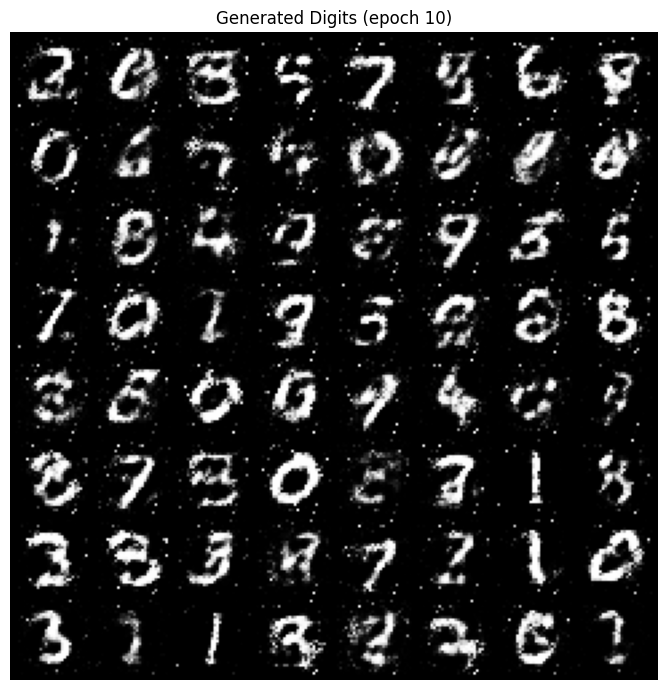

Saved: /content/drive/MyDrive/COMP-341L/Lab 12/Zarmeena's Lab/outputs/samples/epoch_010.png


Epoch 11/15:   0%|          | 0/468 [00:00<?, ?it/s]

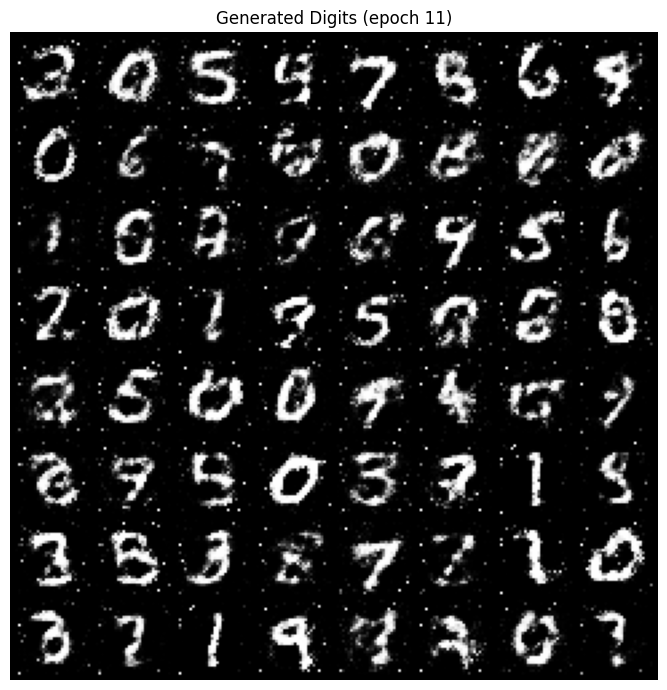

Saved: /content/drive/MyDrive/COMP-341L/Lab 12/Zarmeena's Lab/outputs/samples/epoch_011.png


Epoch 12/15:   0%|          | 0/468 [00:00<?, ?it/s]

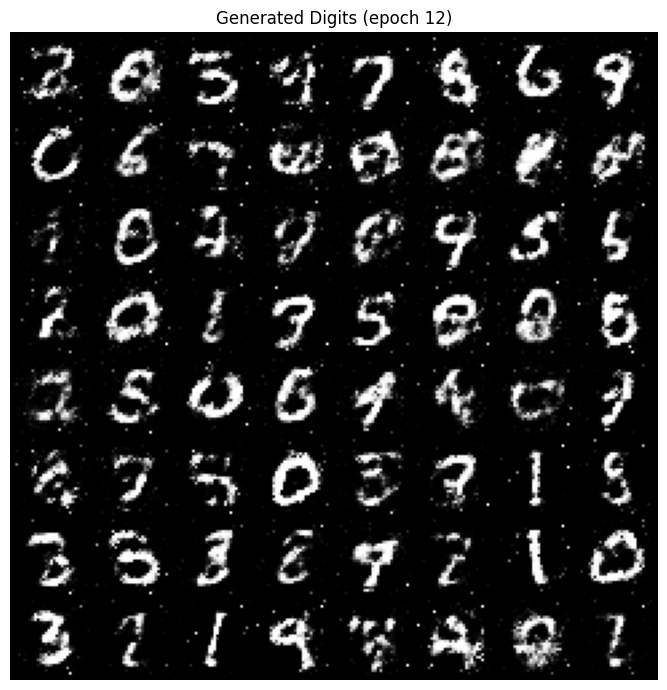

Saved: /content/drive/MyDrive/COMP-341L/Lab 12/Zarmeena's Lab/outputs/samples/epoch_012.png


Epoch 13/15:   0%|          | 0/468 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7c1266d6f920>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    if w.is_alive():
       ^Exception ignored in: ^<function _MultiProcessingDataLoaderIter.__del__ at 0x7c1266d6f920>^
^^Traceback (most recent call last):
^^  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
^^    ^self._shutdown_workers()^
^  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers

      File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
if w.is_alive():    
assert self._parent_pid == os.getpid(), 'can only test a child process'
                ^ ^ ^^^^^^^^^^^^^^^^^^
^  F

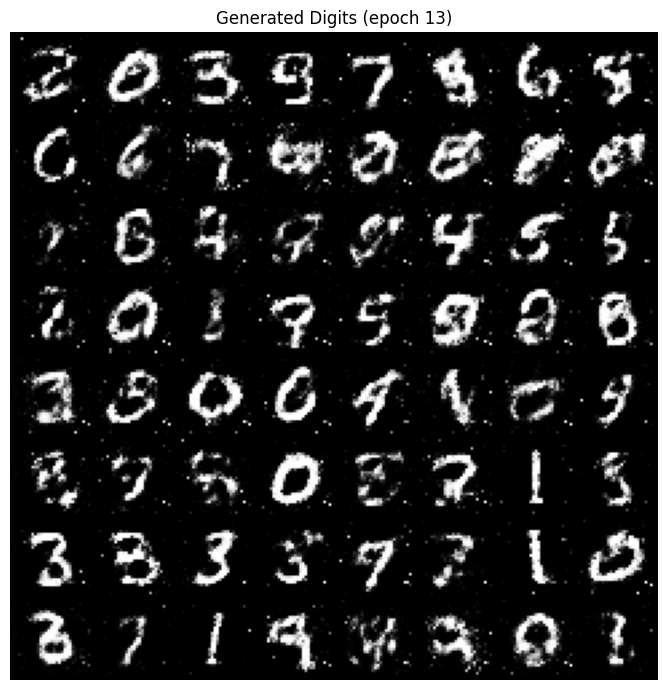

Saved: /content/drive/MyDrive/COMP-341L/Lab 12/Zarmeena's Lab/outputs/samples/epoch_013.png


Epoch 14/15:   0%|          | 0/468 [00:00<?, ?it/s]

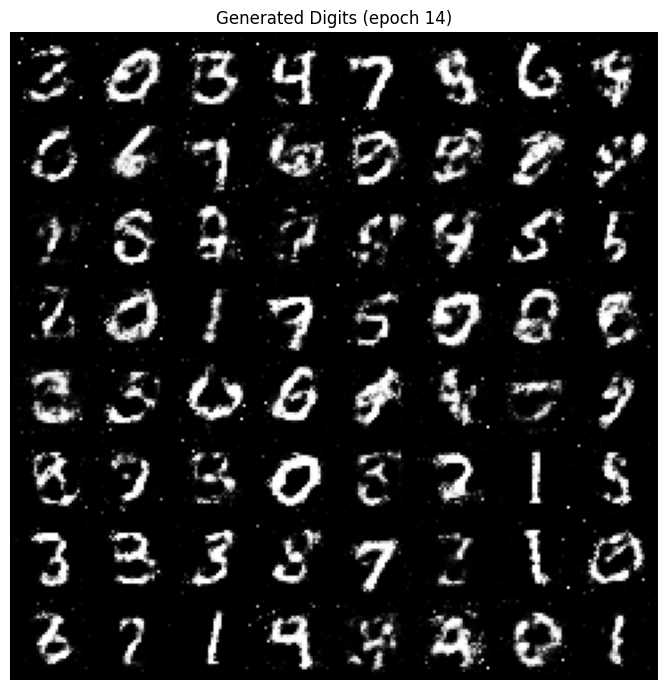

Saved: /content/drive/MyDrive/COMP-341L/Lab 12/Zarmeena's Lab/outputs/samples/epoch_014.png


Epoch 15/15:   0%|          | 0/468 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7c1266d6f920>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    if w.is_alive():
       Exception ignored in: ^<function _MultiProcessingDataLoaderIter.__del__ at 0x7c1266d6f920>^
^Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
^^    ^self._shutdown_workers()
^  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    if w.is_alive():
^  ^ ^ ^  ^ 
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
^    ^^^^assert self._parent_pid == os.getpid(), 'can only test a child process'
^ ^ ^ ^ ^ ^^ 
   File "/usr/lib

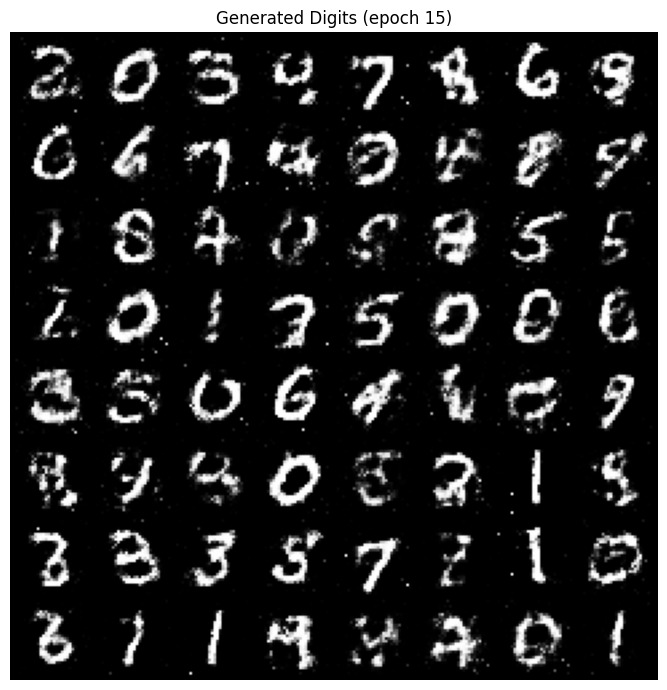

Saved: /content/drive/MyDrive/COMP-341L/Lab 12/Zarmeena's Lab/outputs/samples/epoch_015.png


,epoch,d_loss,g_loss
10,11,1.269253,0.923218
11,12,1.276924,0.903998
12,13,1.286708,0.882647
13,14,1.300484,0.859821
14,15,1.305166,0.846685


Saved: /content/drive/MyDrive/COMP-341L/Lab 12/Zarmeena's Lab/outputs/loss_history.csv


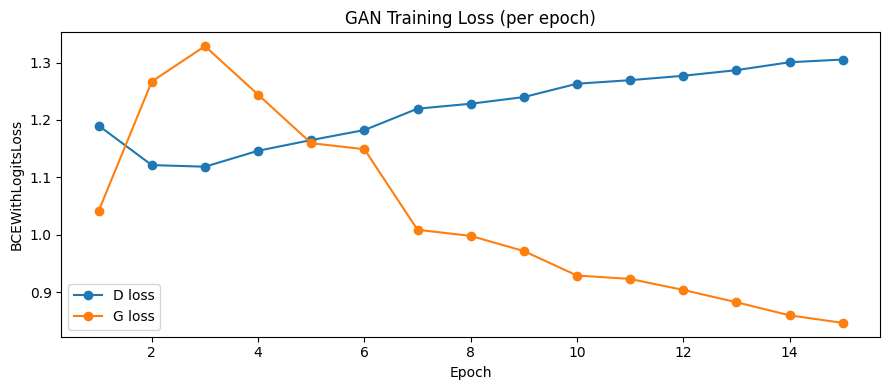

Saved: /content/drive/MyDrive/COMP-341L/Lab 12/Zarmeena's Lab/outputs/plots/task3_epoch_losses.png


In [4]:
criterion = nn.BCEWithLogitsLoss()
opt_G = torch.optim.Adam(G.parameters(), lr=lr, betas=(beta1, beta2))
opt_D = torch.optim.Adam(D.parameters(), lr=lr, betas=(beta1, beta2))

fixed_noise = torch.randn(64, latent_dim, device=DEVICE)

history = []

for epoch in range(1, num_epochs + 1):
    G.train()
    D.train()
    epoch_g = 0.0
    epoch_d = 0.0
    batches = 0

    pbar = tqdm(dataloader, desc=f"Epoch {epoch}/{num_epochs}")
    for real_flat in pbar:
        real_flat = real_flat.to(DEVICE)
        bsz = real_flat.size(0)
        batches += 1

        real_y = torch.ones(bsz, 1, device=DEVICE)
        fake_y = torch.zeros(bsz, 1, device=DEVICE)

        # ---- Train D ----
        opt_D.zero_grad(set_to_none=True)
        real_logits = D(real_flat)
        d_real = criterion(real_logits, real_y)

        z = torch.randn(bsz, latent_dim, device=DEVICE)
        fake_flat = G(z).detach()
        fake_logits = D(fake_flat)
        d_fake = criterion(fake_logits, fake_y)

        d_loss = d_real + d_fake
        d_loss.backward()
        opt_D.step()

        # ---- Train G ----
        opt_G.zero_grad(set_to_none=True)
        z = torch.randn(bsz, latent_dim, device=DEVICE)
        gen_flat = G(z)
        gen_logits = D(gen_flat)
        g_loss = criterion(gen_logits, real_y)  # want D(gen)=1
        g_loss.backward()
        opt_G.step()

        epoch_d += float(d_loss.item())
        epoch_g += float(g_loss.item())

        if batches % 50 == 0:
            pbar.set_postfix({"D": f"{d_loss.item():.3f}", "G": f"{g_loss.item():.3f}"})

    epoch_d /= max(batches, 1)
    epoch_g /= max(batches, 1)
    history.append({"epoch": epoch, "d_loss": epoch_d, "g_loss": epoch_g})

    # Save sample grid each epoch (fixed noise)
    G.eval()
    with torch.no_grad():
        fake_flat = G(fixed_noise).detach().cpu()
    fake_imgs = fake_flat.view(-1, 1, 28, 28)
    grid = torchvision.utils.make_grid(
        fake_imgs, nrow=8, normalize=True, value_range=(-1, 1)
    )
    plt.figure(figsize=(7, 7))
    plt.imshow(grid.permute(1, 2, 0).numpy())
    plt.title(f"Generated Digits (epoch {epoch})")
    plt.axis("off")
    plt.tight_layout()
    sample_path = os.path.join(SAMPLES_DIR, f"epoch_{epoch:03d}.png")
    plt.savefig(sample_path, dpi=170, bbox_inches="tight")
    plt.show()
    print("Saved:", sample_path)

hist_df = pd.DataFrame(history)
display(hist_df.tail())
hist_csv = os.path.join(OUT_DIR, "loss_history.csv")
hist_df.to_csv(hist_csv, index=False)
print("Saved:", hist_csv)

plt.figure(figsize=(9, 4))
plt.plot(hist_df["epoch"], hist_df["d_loss"], marker="o", label="D loss")
plt.plot(hist_df["epoch"], hist_df["g_loss"], marker="o", label="G loss")
plt.title("GAN Training Loss (per epoch)")
plt.xlabel("Epoch")
plt.ylabel("BCEWithLogitsLoss")
plt.legend()
plt.tight_layout()
loss_plot = os.path.join(PLOTS_DIR, "task3_epoch_losses.png")
plt.savefig(loss_plot, dpi=170, bbox_inches="tight")
plt.show()
print("Saved:", loss_plot)


## Task 4 — Visualization (Real vs Fake)

Below is a quick side-by-side comparison: a batch of real digits vs a batch of generated digits.


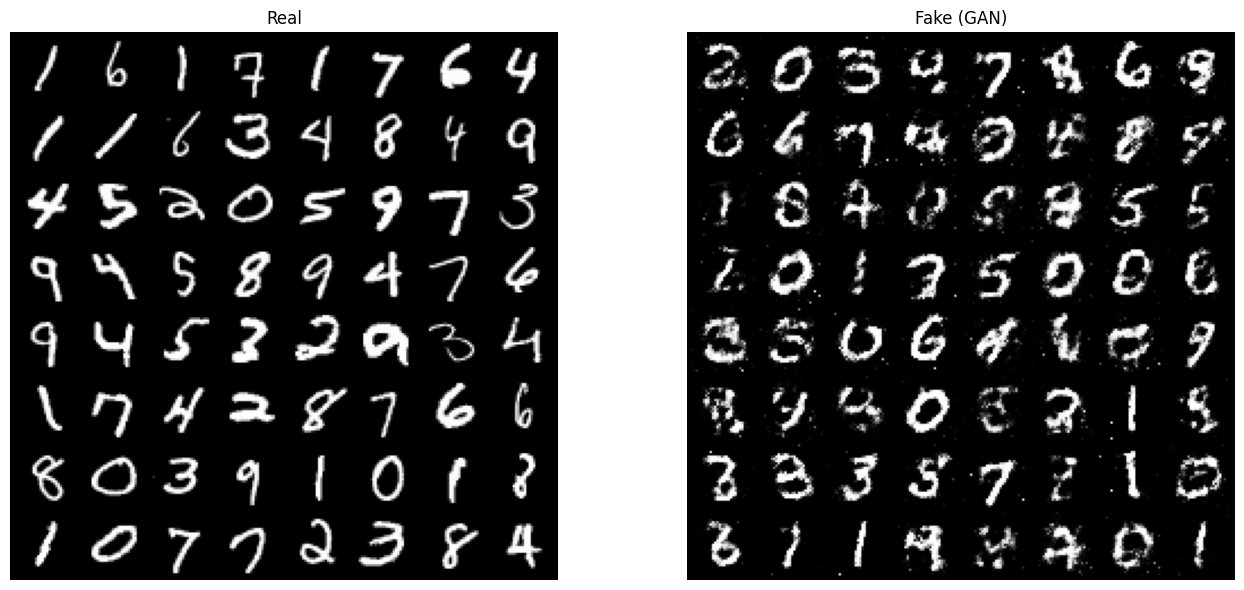

Saved: /content/drive/MyDrive/COMP-341L/Lab 12/Zarmeena's Lab/outputs/plots/task4_real_vs_fake.png


In [5]:
real_flat = next(iter(dataloader))[:64]
real_imgs = real_flat.view(-1, 1, 28, 28)
real_grid = torchvision.utils.make_grid(
    real_imgs, nrow=8, normalize=True, value_range=(-1, 1)
)

with torch.no_grad():
    fake_flat = G(fixed_noise).detach().cpu()
fake_imgs = fake_flat.view(-1, 1, 28, 28)
fake_grid = torchvision.utils.make_grid(
    fake_imgs, nrow=8, normalize=True, value_range=(-1, 1)
)

fig, ax = plt.subplots(1, 2, figsize=(14, 6))
ax[0].imshow(real_grid.permute(1, 2, 0).numpy())
ax[0].set_title("Real")
ax[0].axis("off")
ax[1].imshow(fake_grid.permute(1, 2, 0).numpy())
ax[1].set_title("Fake (GAN)")
ax[1].axis("off")
plt.tight_layout()
path = os.path.join(PLOTS_DIR, "task4_real_vs_fake.png")
plt.savefig(path, dpi=170, bbox_inches="tight")
plt.show()
print("Saved:", path)


## Task 5 — Experimentation (Optional)

Try:
- `latent_dim`: 50, 100, 200
- `lr`: 1e-4, 2e-4, 5e-4

The mini-runner below is OFF by default (so your main training stays clean).


In [6]:
RUN_QUICK_EXPERIMENTS = False


def quick_train(z_dim: int, lr_local: float, epochs: int = 3, max_batches: int = 200):
    g = Generator(z_dim, image_dim).to(DEVICE)
    d = Discriminator(image_dim).to(DEVICE)
    og = torch.optim.Adam(g.parameters(), lr=lr_local, betas=(beta1, beta2))
    od = torch.optim.Adam(d.parameters(), lr=lr_local, betas=(beta1, beta2))

    for _ in range(epochs):
        for bi, real_flat in enumerate(dataloader):
            if bi >= max_batches:
                break
            real_flat = real_flat.to(DEVICE)
            bsz = real_flat.size(0)
            real_y = torch.ones(bsz, 1, device=DEVICE)
            fake_y = torch.zeros(bsz, 1, device=DEVICE)

            # D
            od.zero_grad(set_to_none=True)
            d_loss = criterion(d(real_flat), real_y)
            z = torch.randn(bsz, z_dim, device=DEVICE)
            fake_flat = g(z).detach()
            d_loss = d_loss + criterion(d(fake_flat), fake_y)
            d_loss.backward()
            od.step()

            # G
            og.zero_grad(set_to_none=True)
            z = torch.randn(bsz, z_dim, device=DEVICE)
            g_loss = criterion(d(g(z)), real_y)
            g_loss.backward()
            og.step()

    return float(d_loss.item()), float(g_loss.item())


if RUN_QUICK_EXPERIMENTS:
    configs = [
        {"latent_dim": 50, "lr": 2e-4},
        {"latent_dim": 100, "lr": 2e-4},
        {"latent_dim": 200, "lr": 2e-4},
        {"latent_dim": 100, "lr": 1e-4},
        {"latent_dim": 100, "lr": 5e-4},
    ]

    rows = []
    for cfg in configs:
        d_last, g_last = quick_train(cfg["latent_dim"], cfg["lr"])
        rows.append({**cfg, "d_loss_last": d_last, "g_loss_last": g_last})

    exp_df = pd.DataFrame(rows)
    display(exp_df)
    exp_path = os.path.join(OUT_DIR, "task5_quick_experiments.csv")
    exp_df.to_csv(exp_path, index=False)
    print("Saved:", exp_path)


## Lab Questions (Written Answers)

**1) Why are GANs called “adversarial”?**  
Because two models compete: **G** tries to fool **D**, while **D** tries to catch fake samples.

**2) What happens if discriminator becomes too strong?**  
The generator gets weak/near-zero gradients (no learning signal), so training may stagnate.

**3) What is mode collapse?**  
The generator keeps producing the same limited patterns and ignores diversity in real data.

**4) Why random noise as input?**  
It gives the generator a controllable source of randomness; different noise vectors can map to different digit styles.

**5) Difference between GAN and CNN?**  
GAN is a *training framework* (G vs D). CNN is an *architecture* that can be used inside either network.


In [7]:
# Export Lab Report (Markdown + HTML)
hist_df = pd.DataFrame(history)
final_d = float(hist_df["d_loss"].iloc[-1]) if len(hist_df) else float("nan")
final_g = float(hist_df["g_loss"].iloc[-1]) if len(hist_df) else float("nan")

report_md = f"""# Lab 12 — GANs (MNIST Digits)

**Student:** {STUDENT_NAME}  
**Roll No:** {STUDENT_ROLL}  
**Section:** {STUDENT_SECTION}  
**Date:** {datetime.now().strftime('%B %d, %Y')}

## Task 1 — Data Preparation
- Source used: `{DATA_SOURCE}`
- Normalization: `[-1, 1]`
- Real grid: `outputs/plots/task1_real_grid.png`

## Task 2 — Model Design
- Vanilla GAN (MLP)
- Generator: `z -> 784` pixels, final activation `tanh`
- Discriminator: `784 -> logits`, loss `BCEWithLogitsLoss`

## Task 3 — Training
- Epochs: `{num_epochs}`
- Batch size: `{batch_size}`
- Latent dim: `{latent_dim}`
- Adam lr: `{lr}` (betas `{(beta1, beta2)}`)
- Final epoch losses: D=`{final_d:.4f}`, G=`{final_g:.4f}`
- Loss plot: `outputs/plots/task3_epoch_losses.png`
- Loss CSV: `outputs/loss_history.csv`
- Samples: `outputs/samples/epoch_###.png`

## Task 4 — Visualization
- Comparison: `outputs/plots/task4_real_vs_fake.png`

## Task 5 — Experimentation
Suggested:
- latent_dim: 50 / 100 / 200
- lr: 1e-4 / 2e-4 / 5e-4

## Lab Questions
1. Adversarial: G vs D game (fool vs detect).
2. Too-strong D: G gets weak gradients, can’t improve.
3. Mode collapse: low diversity outputs.
4. Noise input: provides randomness to generate variety.
5. GAN vs CNN: framework vs architecture.
"""

html = f"""<!doctype html>
<html lang="en">
  <head>
    <meta charset="utf-8">
    <meta name="viewport" content="width=device-width, initial-scale=1">
    <title>Lab 12 — GAN Report — {STUDENT_NAME}</title>
    <style>
      :root {{
        --bg: #0b1220;
        --card: #0f1a30;
        --text: #e5e7eb;
        --muted: #a5b4fc;
        --border: rgba(255,255,255,0.10);
        --accent: #22c55e;
      }}
      * {{ box-sizing: border-box; }}
      body {{
        margin: 0;
        font-family: ui-sans-serif, system-ui, -apple-system, Segoe UI, Roboto, Helvetica, Arial;
        background: radial-gradient(1000px 600px at 20% 0%, rgba(34,197,94,0.15), transparent 60%),
                   radial-gradient(900px 500px at 90% 10%, rgba(165,180,252,0.18), transparent 55%),
                   var(--bg);
        color: var(--text);
        line-height: 1.6;
      }}
      .wrap {{ max-width: 980px; margin: 0 auto; padding: 34px 20px 60px; }}
      .hero {{
        border: 1px solid var(--border);
        background: linear-gradient(180deg, rgba(15,26,48,0.9), rgba(15,26,48,0.65));
        border-radius: 16px;
        padding: 26px 22px;
      }}
      h1 {{ margin: 0 0 8px; font-size: 30px; }}
      .sub {{ color: var(--muted); margin: 0 0 16px; }}
      .grid {{ display: grid; grid-template-columns: 1fr 1fr; gap: 12px; }}
      .pill {{
        border: 1px solid var(--border);
        border-radius: 12px;
        padding: 10px 12px;
        background: rgba(255,255,255,0.02);
      }}
      .label {{ font-size: 12px; color: #c7d2fe; margin: 0; }}
      .value {{ margin: 2px 0 0; font-weight: 650; }}
      h2 {{ margin: 22px 0 10px; font-size: 20px; }}
      .card {{
        border: 1px solid var(--border);
        background: rgba(255,255,255,0.03);
        border-radius: 14px;
        padding: 14px 14px;
        margin: 12px 0;
      }}
      .card img {{ max-width: 100%; border-radius: 12px; display: block; margin: 0 auto; }}
      code {{
        background: rgba(255,255,255,0.08);
        padding: 2px 6px;
        border-radius: 8px;
      }}
      ul {{ margin: 8px 0 8px 20px; }}
      .footer {{ margin-top: 18px; color: #c7d2fe; font-size: 12px; }}
    </style>
  </head>
  <body>
    <div class="wrap">
      <div class="hero">
        <h1>Lab 12 — GANs for Synthetic Digits</h1>
        <p class="sub">Vanilla GAN (MLP) • MNIST • Generator vs Discriminator</p>
        <div class="grid">
          <div class="pill"><p class="label">Student</p><p class="value">{STUDENT_NAME}</p></div>
          <div class="pill"><p class="label">Roll No</p><p class="value">{STUDENT_ROLL}</p></div>
          <div class="pill"><p class="label">Section</p><p class="value">{STUDENT_SECTION}</p></div>
          <div class="pill"><p class="label">Date</p><p class="value">{datetime.now().strftime('%B %d, %Y')}</p></div>
        </div>
      </div>

      <h2>Task 1 — Data Preparation</h2>
      <div class="card">
        <ul>
          <li>Source used: <code>{DATA_SOURCE}</code></li>
          <li>Normalization: <code>[-1, 1]</code></li>
        </ul>
        <img src="outputs/plots/task1_real_grid.png" alt="Real grid">
      </div>

      <h2>Task 3 — Training</h2>
      <div class="card">
        <ul>
          <li>Epochs: <code>{num_epochs}</code>, Batch size: <code>{batch_size}</code></li>
          <li>Latent dim: <code>{latent_dim}</code>, Adam lr: <code>{lr}</code></li>
          <li>Final losses: D=<code>{final_d:.4f}</code>, G=<code>{final_g:.4f}</code></li>
        </ul>
        <img src="outputs/plots/task3_epoch_losses.png" alt="Loss plot">
      </div>

      <h2>Task 4 — Real vs Fake</h2>
      <div class="card">
        <img src="outputs/plots/task4_real_vs_fake.png" alt="Real vs Fake">
      </div>

      <h2>Lab Questions (Short)</h2>
      <div class="card">
        <ul>
          <li><strong>Adversarial?</strong> Competition between G and D.</li>
          <li><strong>D too strong?</strong> G gets weak gradients.</li>
          <li><strong>Mode collapse?</strong> Repetitive outputs, low diversity.</li>
          <li><strong>Why noise?</strong> Randomness for variety.</li>
          <li><strong>GAN vs CNN?</strong> Framework vs architecture.</li>
        </ul>
      </div>

      <div class="footer">
        Saved to <code>{BASE_DIR}</code> • Plots in <code>{PLOTS_DIR}</code> • Samples in <code>{SAMPLES_DIR}</code>
      </div>
    </div>
  </body>
</html>
"""

md_path = os.path.join(BASE_DIR, "Lab_Report_12.md")
html_path = os.path.join(BASE_DIR, "Lab_Report_12.html")
with open(md_path, "w", encoding="utf-8") as f:
    f.write(report_md)
with open(html_path, "w", encoding="utf-8") as f:
    f.write(html)

print("Saved:", os.path.abspath(md_path))
print("Saved:", os.path.abspath(html_path))
print("Artifacts:")
for root, _dirs, files in os.walk(OUT_DIR):
    for fn in sorted(files):
        if fn.lower().endswith((".png", ".csv")):
            print(" -", os.path.relpath(os.path.join(root, fn), BASE_DIR))


Saved: /content/drive/MyDrive/COMP-341L/Lab 12/Zarmeena's Lab/Lab_Report_12.md
Saved: /content/drive/MyDrive/COMP-341L/Lab 12/Zarmeena's Lab/Lab_Report_12.html
Artifacts:
 - outputs/loss_history.csv
 - outputs/plots/task1_real_grid.png
 - outputs/plots/task3_epoch_losses.png
 - outputs/plots/task4_real_vs_fake.png
 - outputs/samples/epoch_001.png
 - outputs/samples/epoch_002.png
 - outputs/samples/epoch_003.png
 - outputs/samples/epoch_004.png
 - outputs/samples/epoch_005.png
 - outputs/samples/epoch_006.png
 - outputs/samples/epoch_007.png
 - outputs/samples/epoch_008.png
 - outputs/samples/epoch_009.png
 - outputs/samples/epoch_010.png
 - outputs/samples/epoch_011.png
 - outputs/samples/epoch_012.png
 - outputs/samples/epoch_013.png
 - outputs/samples/epoch_014.png
 - outputs/samples/epoch_015.png
